In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().cwd().parents[1]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = c:\Users\hodor\Documents\lab-MSU\Works\2025.10_TMS\TEP_analysis


In [2]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File
import json
import os 

# graphics
import matplotlib.pyplot as plt 
import seaborn as sns
from mne.viz import plot_topomap
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [3]:
from src.utils.montage_processing import *
filename_colors = r"../../resources/channel_colors.json"
with open(filename_colors, "r") as f:
    EEG64_REGION_COLOR = json.load(f)
CED_FILE = r"../../resources/mks64_standard.ced"
df = pd.read_csv(CED_FILE, sep='\t')
df["colors"] = df["labels"].map(EEG64_REGION_COLOR)
colors = df["colors"].values
positions = get_topo_positions(CED_FILE)

In [4]:
from src.utils.parse_files import *

In [5]:
import h5py

folder = r"..\..\data\exp\session41"
records = os.listdir(folder)

epochs = []
labels = []
fn = r"..\..\data\exp\session_41__set_1__cleaned_SOUND.mat"
for record in records[:2] + records[4:6]:
    with h5py.File(os.path.join(folder, record), "r") as hdf:
        # print(hdf.keys())
        # print(hdf['cleanedResult'].keys())
        tvec = hdf['cleanedResult/tvec'][:][0]
        epoch  = hdf['cleanedResult/epochs_clean'][:] 

        orig = read_matlab_string(hdf, "cleanedResult/sourceDatasets/OriginalFile")
        orig = orig.ravel(order="F").tolist()

        label =  read_matlab_string(hdf, "cleanedResult/epoch_types")
        label = label.ravel(order="F").tolist()
        label = np.asarray([json.loads(l)["stimulus"] for l in label])
        print(orig)
        epochs.append(epoch)
        labels.append(label)

['01_02NS_M1_AP_60MSO_real.hdf5']
['02_02NS_M1_AP_60MSO_MI.hdf5']
['05_02NS_M1_AP_60MSO_realI.hdf5']
['06_02NS_M1_AP_60MSO_MI.hdf5']


In [6]:
epochs = np.concat(epochs, axis=1)
labels = np.concat(labels)

In [7]:
def code_labels(labels, n):
    lab = np.zeros((n, 3))
    lab[np.where(labels == "animatedSingle1500_tms_+200ms_nosounds_bar.mkv"), 0] = 1
    lab[np.where(labels == "animatedSingle1500_tms_0ms_nosounds_bar.mkv"), 1] = 1
    lab[np.where(labels == "rest1500_tms_0ms_bar.mkv"), 2] = 1
    return lab

lab = code_labels(labels, epochs.shape[1])

In [8]:
conds = np.asarray(["real"]*75 + ["MI"]*75 + ["real"]*75 + ["MI"]*75)
real_mask = np.where(conds == "real")[0]
MI_mask = np.where(conds == "MI")[0]
epochs_real = epochs[:, real_mask, :]
epochs_MI = epochs[:, MI_mask, :]
labels_real = lab[real_mask]
labels_MI = lab[MI_mask]
epochs_real.shape, epochs_MI.shape

((64, 150, 4001), (64, 150, 4001))

In [9]:
def get_cond_ask(lab):
    rest_mask = np.where(lab[:, 2] == 1)[0]
    onset_mask = np.where(lab[:, 1] == 1)[0]
    after_mask = np.where(lab[:, 0] == 1)[0]
    return rest_mask, onset_mask, after_mask

rest_real_mask, onset_real_mask, after_real_mask = get_cond_ask(labels_real)
rest_MI_mask, onset_MI_mask, after_MI_mask = get_cond_ask(labels_MI)
rest_mask, onset_mask, after_mask = get_cond_ask(lab)

In [10]:
def detect_tep_peak(
    signal,
    times,
    tmin,
    tmax,
    polarity="negative",
    smooth_window=None,
    mean_around_ms=5,
):
    """
    Поиск пика TEP-компонента в заданном временном окне.

    Parameters
    ----------
    signal : array, shape (n_times,)
        1D сигнал: например ROI-average, один канал или GMFP.
    times : array, shape (n_times,)
        Время в секундах.
    tmin, tmax : float
        Окно поиска в секундах, например 0.09, 0.14 для N100.
    polarity : {"negative", "positive", "absolute"}
        Какой пик искать.
    smooth_window : int | None
        Если задано, сглаживание moving average в точках.
    mean_around_ms : float
        Усреднение амплитуды вокруг найденного пика, в миллисекундах.

    Returns
    -------
    result : dict
        latency, peak_amplitude, mean_amplitude, peak_index
    """

    signal = np.asarray(signal)
    times = np.asarray(times)

    if smooth_window is not None and smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        signal_proc = np.convolve(signal, kernel, mode="same")
    else:
        signal_proc = signal.copy()

    win_mask = (times >= tmin) & (times <= tmax)

    if not np.any(win_mask):
        raise ValueError("В заданном временном окне нет точек.")

    win_signal = signal_proc[win_mask]
    win_times = times[win_mask]
    win_indices = np.where(win_mask)[0]

    if polarity == "negative":
        local_peak = np.argmin(win_signal)
    elif polarity == "positive":
        local_peak = np.argmax(win_signal)
    elif polarity == "absolute":
        local_peak = np.argmax(np.abs(win_signal))
    else:
        raise ValueError("polarity должен быть 'negative', 'positive' или 'absolute'.")

    peak_index = win_indices[local_peak]
    latency = times[peak_index]
    peak_amplitude = signal[peak_index]

    half_win = mean_around_ms / 1000
    mean_mask = (times >= latency - half_win) & (times <= latency + half_win)
    mean_amplitude = signal[mean_mask].mean()

    return {
        "latency": latency,
        "latency_ms": latency * 1000,
        "peak_amplitude": peak_amplitude,
        "mean_amplitude": mean_amplitude,
        "peak_index": peak_index,
    }

In [11]:
ROI_AP_n20 =  ["C3", "C5", "C1", "CP3", "CP5", "CP1", "FC5", "FC3", "FC1"]
ROI_PA_n20 = ["C3", "C5", "C1", "CP3", "CP5", "CP1", "P5", "P3", "P1"]

ROI_AP_n20 =  ["C3", "C5", "C1", "CP3", "FC3"]
ROI_AP_p30 =  ["C3", "C5", "C1", "CP3", "FC3"]
ROI_AP_n20_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_AP_n20]
ROI_PA_n20_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_PA_n20]

In [12]:
def select_component_roi(
    evoked,          # shape: n_channels × n_times
    times,           # seconds
    ch_names,
    tmin,
    tmax,
    polarity="negative",
    top_percent=0.2,
):
    """
    Data-driven ROI selection for one TEP component,
    based on overall component expression, not condition contrast.
    """

    evoked = np.asarray(evoked)
    times = np.asarray(times)

    time_mask = (times >= tmin) & (times <= tmax)

    if polarity == "positive":
        scores = evoked[:, time_mask].mean(axis=1)
    elif polarity == "negative":
        scores = -evoked[:, time_mask].mean(axis=1)
    elif polarity == "absolute":
        scores = np.abs(evoked[:, time_mask]).mean(axis=1)
    else:
        raise ValueError("polarity must be positive, negative, or absolute")

    n_select = max(1, int(np.ceil(len(ch_names) * top_percent)))
    selected_idx = np.argsort(scores)[-n_select:]

    roi_channels = [ch_names[i] for i in selected_idx]

    return {
        "roi_channels": roi_channels,
        "roi_indices": selected_idx,
        "scores": scores,
    }

TEPs = np.mean(epochs[:, rest_mask, :], axis=1)
windows = [(10, 25), (20, 40), (40, 55), (55, 75), (80, 120)]

n20_roi = select_component_roi(
    evoked=TEPs,
    times=tvec,
    ch_names=df["labels"].values,
    tmin=20,
    tmax=40,
    polarity="positive",
    top_percent=0.1,
)


p30_roi = select_component_roi(
    evoked=TEPs,
    times=tvec,
    ch_names=df["labels"].values,
    tmin=20,
    tmax=40,
    polarity="positive",
    top_percent=0.1,
)

p30_roi = select_component_roi(
    evoked=TEPs,
    times=tvec,
    ch_names=df["labels"].values,
    tmin=20,
    tmax=40,
    polarity="positive",
    top_percent=0.1,
)

p30_roi = select_component_roi(
    evoked=TEPs,
    times=tvec,
    ch_names=df["labels"].values,
    tmin=20,
    tmax=40,
    polarity="positive",
    top_percent=0.1,
)

n100_roi = select_component_roi(
    evoked=TEPs,
    times=tvec,
    ch_names=df["labels"].values,
    tmin=90,
    tmax=140,
    polarity="negative",
    top_percent=0.1,
)

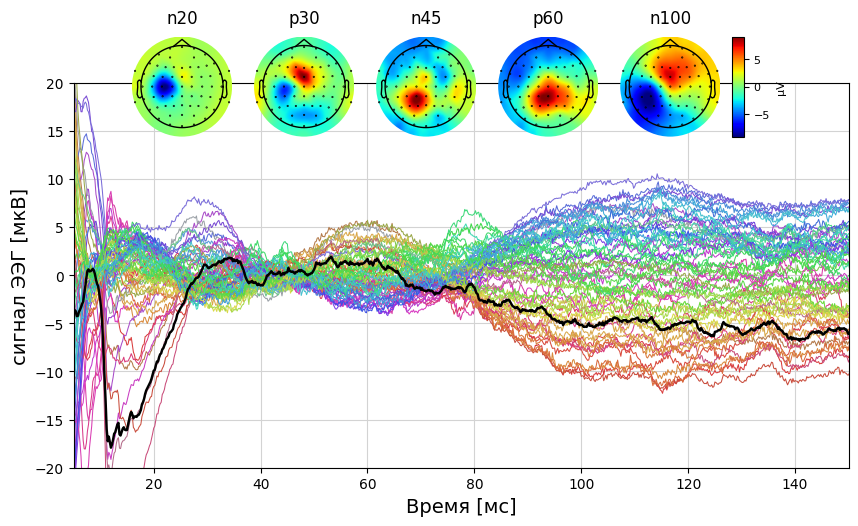

In [13]:
def plot_TEPs(epochs, rest_mask, ROI_idx):
    tmin, tmax = 5, 150
    amp = 20
    comp_names = ["n20", "p30", "n45", "p60", "n100"]
    topo_windows = [(10, 25), (20, 40), (40, 55), (55, 75), (80, 120)]

    def get_mask(tlim, tvec):
        return np.where((tvec >= tlim[0]) & (tvec <= tlim[1]))[0]

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    TEPs = np.mean(epochs[:, rest_mask, :], axis=1)
    TEPs_ROI = np.mean(TEPs[ROI_idx, :], axis=0)
    for color, TEP in zip(colors, TEPs): # начало движения
        ax.plot(tvec, TEP, color=color, linewidth=.75)

    ax.plot(tvec, TEPs_ROI, color="black", linewidth=1.75)
        
    ax.set_xlim(tmin, tmax)
    ax.set_ylim(-amp, amp)
    ax.set_xlabel("Время [мс]", fontsize=14)
    ax.set_ylabel("сигнал ЭЭГ [мкВ]", fontsize=14)
    ax.grid(color="lightgrey")

    # ax.set_title('ТВП в М1 в момент выполнения движения', fontsize=18)

    ax.axvline(0, color="black", linewidth=2)

    topo_size = 0.26
    topo_y = 0.86
    topo_xs = np.linspace(0.01, 0.64, len(topo_windows))

    t = tmin
    for topo_x, tlim,comp_name in zip(topo_xs, topo_windows,comp_names):
        time_mask = get_mask(tlim, tvec)
        TEPs_topo = np.mean(TEPs[:, time_mask], axis=1)

        topo_ax = ax.inset_axes([topo_x, topo_y, topo_size, topo_size])
        im, _ = plot_topomap(
            TEPs_topo,
            positions,
            axes=topo_ax,
            ch_type="eeg",
            image_interp="cubic",
            size=5,
            show=False,
            contours=0,
            sphere=0.55,
            cmap="jet",
            extrapolate="head",
            # vlim=(-amp, amp),
        )
        topo_ax.set_title(comp_name, fontsize=12, y=1.05)

        # a = 0.4
        # ax.axvspan(tlim[0], tlim[1], alpha=a, color='darkgrey', zorder=1)

    cbar_ax = ax.inset_axes([0.85, topo_y, 0.015, topo_size])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("μV", fontsize=8)
    cbar.ax.tick_params(labelsize=8)

plot_TEPs(epochs, rest_mask, ROI_AP_n20_idx)

In [14]:
def get_mask(tlim, tvec):
    return np.where((tvec >= tlim[0]) & (tvec <=tlim[1]))[0]

def plot_tep_topo(TEPs_topo, ax=None, *, amp=None, add_colorbar=True):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    topo_kwargs = {}
    if amp is not None:
        topo_kwargs["vlim"] = (-amp, amp)

    im, cn = plot_topomap(
        TEPs_topo,
        positions,
        axes=ax,
        ch_type="eeg",
        image_interp="cubic",
        size=5,
        show=False,
        contours=0,
        sphere=0.55,
        cmap="jet",
        extrapolate="head",
        **topo_kwargs,
    )

    cbar = None
    if add_colorbar:
        cbar = ax.figure.colorbar(im, ax=ax, fraction=0.05, aspect=20)
        cbar.set_label("μV", fontsize=10)

    return im, cn, cbar

In [15]:
tlim = (15, 25)
time_mask = get_mask(tlim, tvec)

TEPs = np.mean(epoch[:, rest_mask, :], axis=1)
TEPs_topo = np.mean(TEPs[:, time_mask], axis=1)

plot_tep_topo(TEPs_topo, ax=None, amp=None, add_colorbar=True)

IndexError: index 79 is out of bounds for axis 1 with size 75

In [ ]:
from scipy import stats
from mne.stats import spatio_temporal_cluster_1samp_test


(64,)

In [ ]:
def cluster_test_epochs(
    cond_a,
    cond_b,
    times,
    adjacency=None,
    tmin=0.02,
    tmax=0.25,
    p_initial=0.05,
    p_cluster=0.05,
    n_permutations=5000,
    tail=0,
    seed=42,
):
    """
    Cluster-based paired test for TMS-EEG epochs.

    Parameters
    ----------
    cond_a, cond_b : np.ndarray
        Shape: n_channels × n_epochs × n_samples.
        Conditions must have the same shape.
    times : np.ndarray
        Time vector in seconds, shape: n_samples.
    adjacency : scipy sparse matrix | None
        Channel adjacency matrix. If None, clustering will be only over time.
    """

    assert cond_a.shape == cond_b.shape
    assert cond_a.ndim == 3

    n_channels, n_epochs, n_samples = cond_a.shape
    assert len(times) == n_samples

    # crop time window
    time_mask = (times >= tmin) & (times <= tmax)
    times_crop = times[time_mask]

    a = cond_a[:, :, time_mask]
    b = cond_b[:, :, time_mask]

    # paired difference
    diff = a - b  # channels × epochs × times

    # MNE wants: observations × times × channels
    X = np.transpose(diff, (1, 2, 0))  # epochs × times × channels

    # cluster-forming threshold
    df = n_epochs - 1

    if tail == 0:
        threshold = stats.t.ppf(1 - p_initial / 2, df)
    elif tail == 1:
        threshold = stats.t.ppf(1 - p_initial, df)
    elif tail == -1:
        threshold = -stats.t.ppf(1 - p_initial, df)
    else:
        raise ValueError("tail must be -1, 0, or 1")

    T_obs, clusters, cluster_p_values, H0 = spatio_temporal_cluster_1samp_test(
        X,
        threshold=threshold,
        n_permutations=n_permutations,
        tail=tail,
        adjacency=adjacency,
        out_type="mask",
        seed=seed,
        n_jobs=-1,
    )

    significant = np.where(cluster_p_values < p_cluster)[0]

    return {
        "T_obs": T_obs,                  # times × channels
        "clusters": clusters,            # list of masks
        "cluster_p_values": cluster_p_values,
        "significant": significant,
        "times": times_crop,
        "X": X,
        "H0": H0,
    }

def describe_cluster(res, cluster_id, ch_names=None):
    mask = res["clusters"][cluster_id]  # times × channels

    time_idx, ch_idx = np.where(mask)

    t_start = res["times"][time_idx.min()]
    t_end = res["times"][time_idx.max()]

    if ch_names is not None:
        channels = sorted(set(ch_names[i] for i in ch_idx))
    else:
        channels = sorted(set(ch_idx))

    return {
        "p": res["cluster_p_values"][cluster_id],
        "t_start": t_start,
        "t_end": t_end,
        "channels": channels,
    }

for cl in res["significant"]:
    print(describe_cluster(res, cl, ch_names=ch_names))

NameError: name 'res' is not defined